# 05 – Saving the Model and Looking Inside It

> **Project notebooks:** [01 Exploration](01_exploration.ipynb) · [02 Modelling](02_modelling.ipynb) · [03 Improvements](03_improvements.ipynb) · [04 Pipelines](04_pipelines.ipynb) · [05 Saving & explaining](05_saving_and_explaining.ipynb)

A model that only lives inside a notebook is not very useful. In a real project two more questions always come up:

1. **"How do we use this model tomorrow, without retraining it?"** → move the code into a Python module and save the fitted pipeline to a file.
2. **"Why should we trust it? When is it wrong?"** → error analysis and SHAP values.

**Contents**
1. Reusable code: the `src/` module
2. Saving and loading the pipeline with `joblib`
3. Error analysis: where is the model wrong?
4. SHAP: why does the model predict what it predicts?
5. What we learned

## 1. Reusable code: the `src/` module

In notebook 04 we wrote the `TitanicFeatures` class inside the notebook. That is fine for learning, but code inside a notebook cannot be used by other notebooks or scripts.
So the class and the pipeline now live in ordinary Python files:

```
src/
├── features.py    # the TitanicFeatures transformer
├── pipeline.py    # make_titanic_pipeline(): features → prepare → model
├── train.py       # script: train on train.csv and save the model
└── predict.py     # script: load the saved model and predict a CSV
```

**Why real projects do this**
- **One source of truth.** Fix a bug in `features.py` once and every notebook and script gets the fix.
- **Saving the model requires it.** A saved pipeline remembers *where* its classes are defined (`src.features.TitanicFeatures`). A class defined in a notebook cannot be found again later.
- **Scripts can run without a notebook**, for example every night on new data.

The notebook lives in `notebooks/`, one level below the project folder, so we first tell Python where to find `src`.

In [1]:
import sys
sys.path.append("..")   # the project folder, where src/ lives

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from src.pipeline import make_titanic_pipeline

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 60)

df = pd.read_csv("../data/train.csv")
test_raw = pd.read_csv("../data/test.csv")
X_raw, y = df.drop(columns="Survived"), df["Survived"]

pipeline = make_titanic_pipeline()
pipeline

Pipeline(steps=[('features', TitanicFeatures()),
                ('prepare',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Pclass', 'Age', 'Fare',
                                                   'FamilySize', 'HasCabin']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Deck'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, random_state=42,
                                            subsample=0.8))])

`make_titanic_pipeline()` builds the same pipeline as notebook 04, with a tree depth of 3 (the best value in the grid search there).
One small change: the encoder now uses `drop="if_binary"`, so `Sex` becomes a single column `Sex_male` instead of two columns that say the same thing. This makes the explanations in section 4 easier to read.

## 2. Saving and loading the pipeline with `joblib`

`joblib.dump` writes a fitted object to a file. `joblib.load` reads it back. The loaded pipeline contains **everything it learned**: the median ages per title, the categories, and all the trees of the model.

In [2]:
from pathlib import Path

pipeline.fit(X_raw, y)

model_path = Path("../models/titanic_pipeline.joblib")
model_path.parent.mkdir(exist_ok=True)
joblib.dump(pipeline, model_path)

print(f"Saved to {model_path} ({model_path.stat().st_size / 1024:.0f} KB)")
print(f"Trained with scikit-learn {sklearn.__version__}")

Saved to ../models/titanic_pipeline.joblib (175 KB)
Trained with scikit-learn 1.2.2


In [3]:
loaded_pipeline = joblib.load(model_path)   # no training happens here

same = (loaded_pipeline.predict(test_raw) == pipeline.predict(test_raw)).all()
print(f"Loaded pipeline gives the same {len(test_raw)} predictions as the original: {same}")

loaded_pipeline.predict_proba(test_raw.head(3))[:, 1].round(3)

Loaded pipeline gives the same 418 predictions as the original: True


array([0.098, 0.489, 0.081])

**Three things professionals know about saved models**

| Rule | Why |
|---|---|
| **Only load files you trust.** | A `.joblib` file can run code when it is loaded. Never open one from an unknown source. |
| **Record the library versions.** | A model saved with one scikit‑learn version may not load in another. That is why we printed the version above and keep `requirements.txt`. |
| **Do not commit the model file to git.** | It is a large binary file that can always be recreated from the code and the data. `models/*.joblib` is listed in `.gitignore`. |

### The same thing from the terminal

Because the code is in `src/`, the model can be trained and used **without opening a notebook**. Run these from the project folder:

```bash
python -m src.train                    # trains and saves models/titanic_pipeline.joblib
python -m src.predict data/test.csv    # loads the saved model and predicts
```

## 3. Error analysis: where is the model wrong?

One accuracy number hides a lot. A good data scientist always looks at the **mistakes**: are they random, or does the model fail for certain kinds of passengers?

To be fair to the model we need predictions for passengers it has **not seen during training**. `cross_val_predict` gives exactly that: every passenger is predicted by a model that was trained on the other four folds. These are called **out‑of‑fold** predictions.

Accuracy:  0.845
Precision: 0.829  (of the passengers we predicted to survive, how many did?)
Recall:    0.751  (of the passengers who survived, how many did we find?)


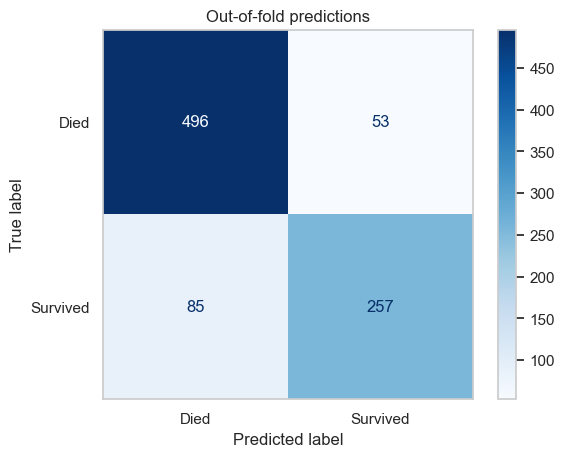

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
survival_chance = cross_val_predict(make_titanic_pipeline(), X_raw, y, cv=cv, method="predict_proba")[:, 1]

results = df.copy()
results["SurvivalChance"] = survival_chance.round(3)
results["Predicted"] = (survival_chance >= 0.5).astype(int)
results["Correct"] = results["Predicted"] == results["Survived"]

print(f"Accuracy:  {accuracy_score(y, results['Predicted']):.3f}")
print(f"Precision: {precision_score(y, results['Predicted']):.3f}  (of the passengers we predicted to survive, how many did?)")
print(f"Recall:    {recall_score(y, results['Predicted']):.3f}  (of the passengers who survived, how many did we find?)")

ConfusionMatrixDisplay.from_predictions(y, results["Predicted"], display_labels=["Died", "Survived"], cmap="Blues")
plt.title("Out-of-fold predictions")
plt.grid(False)
plt.show()

The model makes two different kinds of mistake:

- **85 missed survivors** (bottom left): the model said "died" but the passenger survived.
- **53 false alarms** (top right): the model said "survived" but the passenger died.

It misses survivors more often than it raises false alarms, which is why recall (0.75) is lower than precision (0.83). The model is **cautious about predicting survival**.

### Who are the mistakes?

In [5]:
by_group = results.groupby(["Sex", "Pclass"]).agg(
    passengers=("Correct", "size"),
    survival_rate=("Survived", "mean"),
    errors=("Correct", lambda s: (~s).sum()),
    error_rate=("Correct", lambda s: 1 - s.mean()),
).round(2)
by_group

passengers  survival_rate  errors  error_rate
Sex    Pclass                                               
female 1               94           0.97       3        0.03
       2               76           0.92       6        0.08
       3              144           0.50      41        0.28
male   1              122           0.37      43        0.35
       2              108           0.16       8        0.07
       3              347           0.14      37        0.11

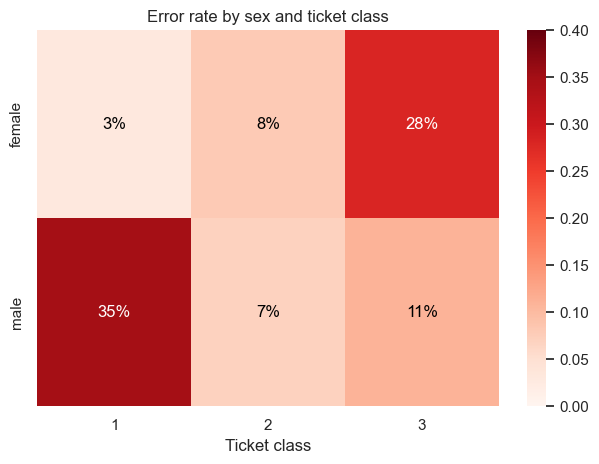

In [6]:
error_table = by_group["error_rate"].unstack("Pclass")

ax = sns.heatmap(error_table, cmap="Reds", vmin=0, vmax=0.4)
for row in range(error_table.shape[0]):          # write the number into every cell
    for col in range(error_table.shape[1]):
        value = error_table.iloc[row, col]
        ax.text(col + 0.5, row + 0.5, f"{value:.0%}", ha="center", va="center",
                color="white" if value > 0.2 else "black")
ax.set(title="Error rate by sex and ticket class", xlabel="Ticket class", ylabel="")
plt.tight_layout()
plt.savefig("../images/error_rate_by_group.png", dpi=120)
plt.show()

The errors are **not** spread evenly. Two groups cause most of them:

| Group | Error rate | Why it is hard |
|---|---|---|
| **Men in 1st class** | 35% | 37% of them survived. The model mostly predicts "died" for men, so it misses many of these survivors. |
| **Women in 3rd class** | 28% | Exactly half of them survived: almost a coin flip. Sex says "survived", class says "died". |

For the other four groups the model is right about 9 times out of 10, because the outcome there was much more one‑sided (97% of 1st‑class women survived, 86% of 3rd‑class men died).

This tells us **where new features could help**: anything that separates the 3rd‑class women who survived from those who did not, or the 1st‑class men who got into a lifeboat from those who did not.

### The most confident mistakes

The most interesting errors are the ones where the model was **very sure and still wrong**.

In [7]:
mistakes = results[~results["Correct"]].copy()
mistakes["Confidence"] = np.where(mistakes["Predicted"] == 1,
                                  mistakes["SurvivalChance"], 1 - mistakes["SurvivalChance"])
mistakes["Actual"] = mistakes["Survived"].map({0: "Died", 1: "Survived"})

mistakes.sort_values("Confidence", ascending=False)[
    ["Name", "Sex", "Age", "Pclass", "SibSp", "Parch", "Fare", "Actual", "SurvivalChance"]
].head(8)

,Name,Sex,Age,Pclass,SibSp,Parch,Fare,Actual,SurvivalChance
570,"Harris, Mr. George",male,62.0,2,0,0,10.5000,Survived,0.050
297,"Allison, Miss. Helen Loraine",female,2.0,1,1,2,151.5500,Died,0.948
498,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1,1,2,151.5500,Died,0.938
271,"Tornquist, Mr. William Henry",male,25.0,3,0,0,0.0000,Survived,0.066
177,"Isham, Miss. Ann Elizabeth",female,50.0,1,0,0,28.7125,Died,0.931
338,"Dahl, Mr. Karl Edwart",male,45.0,3,0,0,8.0500,Survived,0.073
804,"Hedman, Mr. Oskar Arvid",male,27.0,3,0,0,6.9750,Survived,0.074
25,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)",female,38.0,3,1,5,31.3875,Survived,0.075


Two patterns stand out:

- **The Allison family.** Helen (age 2) and her mother Bessie were 1st‑class females, so the model gave them a ~94% chance. In reality almost the whole family died together: they stayed on board searching for the baby, who had already been taken to a lifeboat by his nurse. No model that looks at passengers **one at a time** can know this. It is exactly what the *group survival* feature in [notebook 03](03_improvements.ipynb) captures, and why that feature raised our Kaggle score.
- **Lucky men.** Several men travelling alone in 2nd or 3rd class survived although the model gave them under 10%. Nothing in their data distinguishes them from the hundreds of similar men who died. Some outcomes simply depended on chance, such as where a person stood when a lifeboat was launched.

**Lesson:** some errors point to missing features (the Allisons), others to real randomness (the lucky men). No model will reach 100% on this data, and knowing *why* is more valuable than one more point of accuracy.

## 4. SHAP: why does the model predict what it predicts?

Gradient Boosting combines 100 trees, so we cannot read it like a simple rule. **SHAP** (SHapley Additive exPlanations) opens the box. For every single prediction it answers:

> *"How much did each feature push this passenger's prediction up or down, compared with the average passenger?"*

The pushes of all features, added to the average, give exactly the model's prediction. So SHAP explains each prediction completely.

SHAP explains the **model**, not the pipeline, so we first run the cleaning steps to get the table of numbers the model actually sees.

In [8]:
import shap

prepare_steps = pipeline[:-1]                     # everything except the model
model = pipeline.named_steps["model"]
feature_names = pipeline.named_steps["prepare"].get_feature_names_out()

X_prepared = pd.DataFrame(prepare_steps.transform(X_raw), columns=feature_names, index=X_raw.index)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_prepared)

print(f"SHAP values: {shap_values.shape[0]} passengers × {shap_values.shape[1]} features")
X_prepared.head(3)

SHAP values: 891 passengers × 21 features


,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,...,Title_Mr,Title_Mrs,Title_Rare,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_U
0,3.0,22.0,7.2500,2.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,38.0,71.2833,2.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3.0,26.0,7.9250,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Which features matter most overall?

The bar chart shows the **average size** of each feature's push, over all passengers.

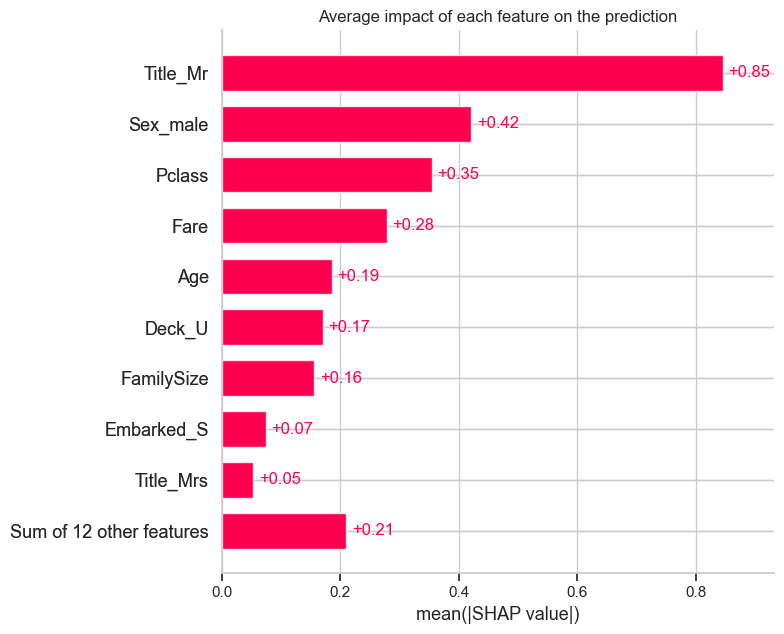

In [9]:
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title("Average impact of each feature on the prediction")
plt.tight_layout()
plt.savefig("../images/shap_importance.png", dpi=120, bbox_inches="tight")
plt.show()

`Title_Mr` is by far the most important feature, followed by `Sex_male`, `Pclass` and `Fare`.

Why is `Title_Mr` ahead of `Sex_male`? Because "Mr" means **adult man**, which combines sex and age in one column. Boys have the title "Master" and survived much more often, so the title is more precise than sex alone. The two columns share the "being male" effect between them.

### In which direction does each feature push?

The next chart (a "beeswarm") shows **one dot per passenger** for every feature:
- position **right** of the line = pushed towards *survived*, **left** = towards *died*,
- **red** = the feature has a high value for that passenger, **blue** = a low value.

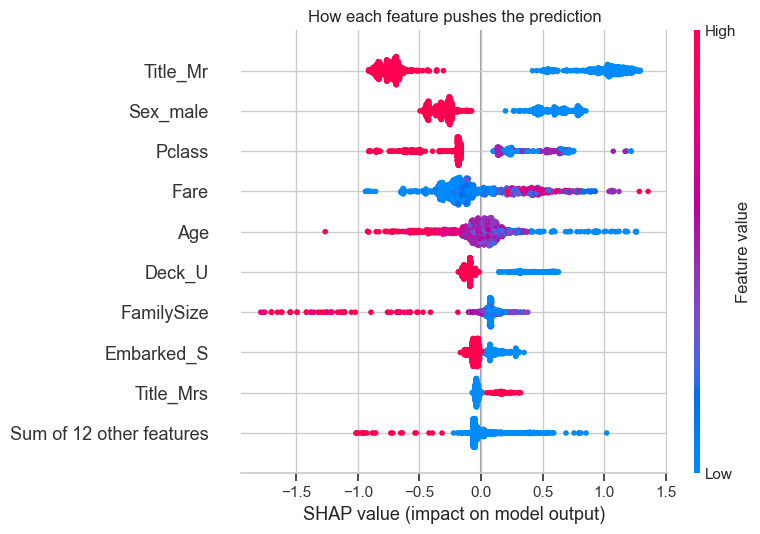

In [10]:
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("How each feature pushes the prediction")
plt.tight_layout()
plt.savefig("../images/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

How to read a few rows:

- **`Title_Mr`**: red dots (the passenger *is* a "Mr") are all on the left, blue dots on the right. Being an adult man strongly lowers the predicted chance; not being one raises it.
- **`Pclass`**: red (3rd class) is on the left, blue (1st class) on the right.
- **`Fare`**: expensive tickets (red) push towards survival.
- **`Age`**: older passengers (red) are pushed towards "died", young children (blue) towards "survived".
- **`FamilySize`**: the long red tail on the left shows that **large families** were pushed strongly towards "died". For most passengers the effect is small.
- **`Deck_U`**: an unknown cabin (red) lowers the chance a little.

This matches what we saw in the charts of notebook 01, which is reassuring: the model learned the real patterns in the data, not something strange.

### How does age change the prediction?

A scatter plot of one feature shows the **shape** of its effect. Each dot is a passenger; the colour shows whether the passenger is male.

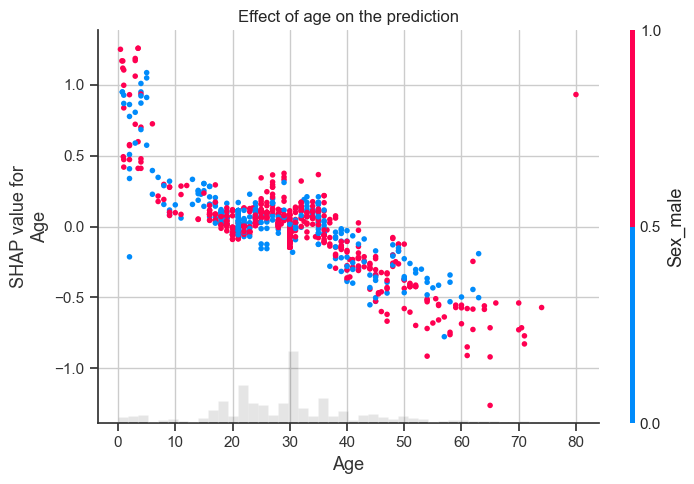

In [11]:
shap.plots.scatter(shap_values[:, "Age"], color=shap_values[:, "Sex_male"], show=False)
plt.title("Effect of age on the prediction")
plt.tight_layout()
plt.show()

- **Young children** (under about 6) get a strong push towards survival, for boys and girls alike.
- Between about **15 and 35** age makes almost no difference.
- From about **40** the effect turns negative and keeps falling with age.
- The lonely dot at **age 80** is pushed strongly *up*, against the trend. That is Mr. Algernon Barkworth, the only 80‑year‑old on board, who survived. The model has partly **memorised one passenger**. This is what overfitting looks like, and a chart like this is a good way to spot it.

The age effect is not a straight line, which is why tree models, which can learn such shapes, do well on this data.

### Explaining a single prediction

A "waterfall" chart explains **one passenger**. Read it from the bottom: start at the average prediction for all passengers, then each feature pushes the value up (red) or down (blue) until we reach this passenger's prediction at the top.

The numbers are in **log‑odds**, the scale the model works in: 0 means a 50% chance, positive means more likely to survive, negative less likely. We print the final chance as a percentage as well.

Harris, Mr. George: predicted survival chance 11%, actually survived


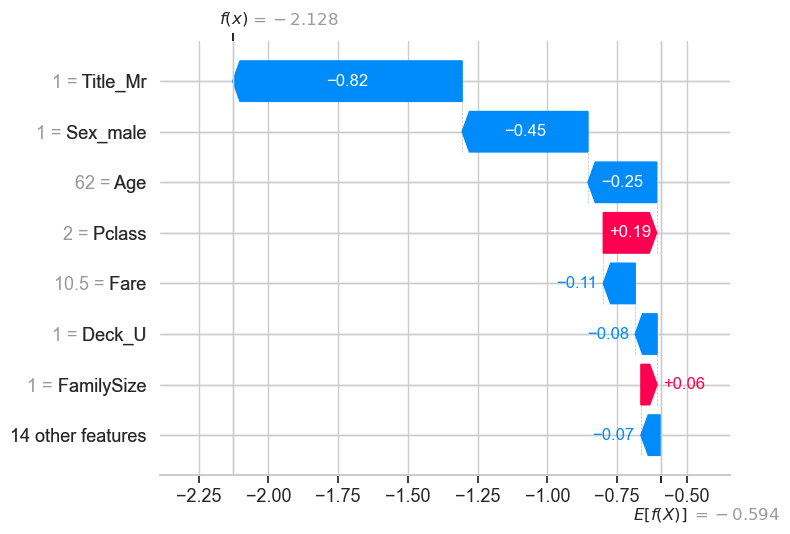

In [12]:
def explain_passenger(index):
    chance = pipeline.predict_proba(X_raw.loc[[index]])[0, 1]
    actual = "survived" if y.loc[index] == 1 else "died"
    print(f"{df.loc[index, 'Name']}: predicted survival chance {chance:.0%}, actually {actual}")
    shap.plots.waterfall(shap_values[X_raw.index.get_loc(index)], max_display=8, show=False)
    plt.tight_layout()
    plt.show()


explain_passenger(df.index[df["Name"].str.startswith("Harris, Mr. George")][0])

**Mr. George Harris** was one of the confident mistakes from section 3: he survived, but the model gives him only 11%.

The chart shows why. Starting from the average (−0.59), being a "Mr" (−0.82), being male (−0.45) and being 62 years old (−0.25) all push down. Only his 2nd‑class ticket helps a little (+0.19). From the model's point of view this is a perfectly reasonable prediction: most men like him died. He was one of the lucky ones.

Allison, Miss. Helen Loraine: predicted survival chance 72%, actually died


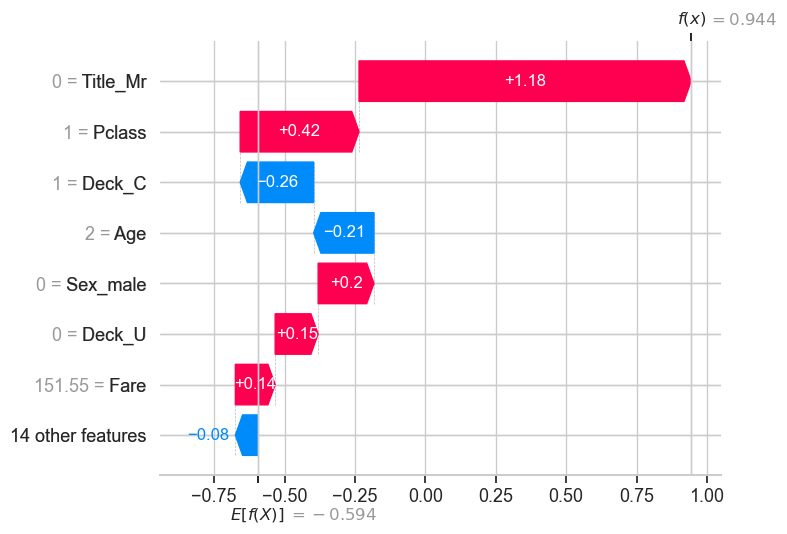

In [13]:
explain_passenger(df.index[df["Name"].str.startswith("Allison, Miss. Helen")][0])

**Helen Allison**, age 2, died, but the model gives her 72%. Not being a "Mr" (+1.18), 1st class (+0.42) and being female (+0.20) all push her towards survival.

One detail is worth noticing: her age of 2 pushes the prediction **down** (−0.21), although the age chart above shows that toddlers are normally pushed strongly *up*. She is the single low dot at age 2 in that chart. The reason is that this model was trained on all 891 passengers, **including Helen herself**, so it has partly memorised that this particular toddler died. In section 3, where she was predicted by a model that had never seen her, her chance was 95%.

This is why error analysis must use out‑of‑fold predictions: a model always looks better on passengers it has already seen.

## 5. What we learned

| Concept | In one sentence |
|---|---|
| **`src/` module** | Code that is used more than once belongs in Python files, not in notebooks. |
| **`joblib.dump` / `joblib.load`** | Save a fitted pipeline once and reuse it without retraining. |
| **Out‑of‑fold predictions** | `cross_val_predict` gives an honest prediction for every training passenger. |
| **Precision and recall** | Two kinds of mistake (false alarms and misses) that a single accuracy number hides. |
| **Error analysis** | Look at *who* the model gets wrong: the errors show where new features could help and where the data is simply random. |
| **SHAP values** | Show how much each feature pushes each prediction up or down, overall and for one passenger. |

**What the model actually learned:** "women and children first, and the rich before the poor". Being an adult man is the strongest signal against survival, and a higher class and fare the strongest in favour. Its biggest blind spot is that it judges every passenger alone, while in reality families acted together.

**Why this matters in a real job:** people will only act on a model's predictions if you can explain them and are honest about where it fails. Being able to say *"the model is right 9 times out of 10 for these groups, but only 2 out of 3 for 1st‑class men, and here is why"* is worth more than an extra point of accuracy.